# Imports

In [1]:
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.0 MB/s eta 0:00:00


In [8]:
import os
import glob
import json
import re
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv, LayerNorm as GraphLayerNorm

from sklearn.metrics import (precision_score, recall_score, f1_score, fbeta_score,
                             average_precision_score, roc_auc_score, confusion_matrix,
                             precision_recall_curve)

import ipaddress
import pickle

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch



In [3]:
# Change directory
os.chdir('/content/drive/MyDrive/nids-mitre/')

!pwd


/content/drive/MyDrive/nids-mitre


# Load data

In [4]:
class NF_IDS_Dataset(Dataset):
    def __init__(self, root_dir, split='train'):
        # root_dir: (eg: "./dataset_processed")
        # split: 'train', 'val' or 'test'
        self.split_dir = os.path.join(root_dir, split)
        super().__init__(self.split_dir)

        # List files ordered numerically to respect the time
        self.files = sorted(
            [f for f in os.listdir(self.split_dir) if f.endswith('.pt')],
            key=lambda x: int(x.split('_')[1].split('.')[0])
        )

    def len(self):
        return len(self.files)

    def get(self, idx):
        data = torch.load(
            os.path.join(self.split_dir, self.files[idx]),
            weights_only=False # to allow loading complex graph objects
        )
        return data

# Evaluate and metrics

In [5]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, is_temporal=False):
    """
    Just run the model and return Loss and raw Probabilities
    """
    model.eval()
    if is_temporal and hasattr(model, 'reset_memory'): model.reset_memory()

    all_probs = []
    all_trues = []
    total_loss = 0
    steps = 0

    # Don't need enumerate here because we're not doing backprop
    for data in loader:
        data = data.to(device)
        if data.x.shape[0] == 0: continue

        use_stats = getattr(model, 'use_node_stats', False)

        # Forward
        if is_temporal:
            if use_stats:
                # ST-GNN
                out = model(data.x, data.edge_index, data.edge_attr, data.global_node_ids, data.node_stats)
            else:
                # EdgeGRU
                out = model(data.x, data.edge_index, data.edge_attr, data.global_node_ids)
        else:
            if use_stats:
                # StaticGNN
                out = model(data.x, data.edge_index, data.edge_attr, data.node_stats)
            else:
                # SimpleMLP
                out = model(data.x, data.edge_index, data.edge_attr)

        # 1. Loss (using logits)
        loss = criterion(out.view(-1), data.y)
        total_loss += loss.item()

        # 2. Probs (using sigmoid)
        probs = torch.sigmoid(out.view(-1))
        all_probs.extend(probs.cpu().numpy())
        all_trues.extend(data.y.cpu().numpy())
        steps += 1

    avg_loss = total_loss / steps if steps > 0 else 0.0

    # Only return the raw data
    return avg_loss, np.array(all_trues), np.array(all_probs)

In [6]:
def calculate_metrics_gnn(y_true, y_probs, prob_threshold=0.5):
    """
    y_true: Array of actual labels (0 or 1)
    y_probs: Array de PROBABILITIES (0.0 to 1.0). NO LOGITS.
    """
    y_true = np.array(y_true)
    probs = np.array(y_probs)

    # Predictions (0 or 1) using the threshold
    preds = (probs > prob_threshold).astype(int)

    # Threshold-dependent metrics
    prec = precision_score(y_true, preds, zero_division=0)
    rec = recall_score(y_true, preds, zero_division=0)
    f1 = f1_score(y_true, preds, zero_division=0)
    f2 = fbeta_score(y_true, preds, beta=2, zero_division=0)

    # Threshold-independent metrics
    try:
        ap = average_precision_score(y_true, probs)
        roc = roc_auc_score(y_true, probs)
    except ValueError:
        # This occurs if y_true has only one class (e.g., only benign in the batch)
        ap = 0.0; roc = 0.5

    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    return {
        "Precision": prec, "Recall": rec, "F1": f1, "F2": f2,
        "AUC-PR": ap, "AUC-ROC": roc, "FPR": fpr,
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn)
    }

# ST-GNN entropy

In [7]:
class ST_GNN_Identity_Entropy(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim, dropout=0.2, output_bias_init=None):
        super(ST_GNN_Identity_Entropy, self).__init__()

        self.use_node_stats = True

        self.hidden_dim = hidden_dim
        self.dropout_rate = dropout

        # IDENTITY PROJECTION
        # Layer to transform the raw edge attributes into a node vector
        self.edge_proj = nn.Linear(edge_dim, node_dim)

        # GNN INPUT DIMENSIONS
        # Since (What the IP sends + What the IP receives) will be concatenated, the input is double.
        gnn_input_dim = (2 * node_dim) + 2

        # GNN LAYER 1
        self.gnn1 = GATv2Conv(
            in_channels=gnn_input_dim,
            out_channels=hidden_dim,
            edge_dim=edge_dim,
            heads=2,
            concat=False,
            dropout=dropout
        )
        self.norm1 = GraphLayerNorm(hidden_dim) # to stabilize traffic features

        # GNN LAYER 2
        self.gnn2 = GATv2Conv(
            in_channels=hidden_dim,
            out_channels=hidden_dim,
            edge_dim=edge_dim,
            heads=1,
            concat=False,
            dropout=dropout
        )
        self.norm2 = GraphLayerNorm(hidden_dim) # to stabilize traffic features

        # TEMPORAL (GRU)
        self.gru = nn.GRUCell(input_size=hidden_dim, hidden_size=hidden_dim)

        # EDGE CLASSIFIER
        classifier_input_dim = (2 * hidden_dim) + edge_dim

        self.classifier = nn.Sequential(
            nn.Linear(classifier_input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

        # Bias Init
        if output_bias_init is not None:
            self.classifier[-1].bias.data.fill_(output_bias_init)

        self.node_memory = {}

    # --- UTILS ---
    def manual_scatter_mean(self, src, index, dim_size):
        out = torch.zeros((dim_size, src.size(1)), device=src.device)
        out.index_add_(0, index, src)

        ones = torch.ones(src.size(0), 1, device=src.device)
        count = torch.zeros(dim_size, 1, device=src.device)
        count.index_add_(0, index, ones)

        count[count < 1] = 1
        return out / count

    def get_memory(self, ids, device):
        mem_list = []
        for i in ids:
            i = i.item()
            if i in self.node_memory:
                mem_list.append(self.node_memory[i])
            else:
                mem_list.append(torch.zeros(self.hidden_dim, device=device))
        return torch.stack(mem_list)

    def update_memory(self, ids, h_new):
        h_stored = h_new.clone()
        for idx, global_id in enumerate(ids):
            self.node_memory[global_id.item()] = h_stored[idx]

    def detach_all_memory(self):
        for k in self.node_memory:
            self.node_memory[k] = self.node_memory[k].detach()

    def reset_memory(self):
        self.node_memory = {}

    def forward(self, x, edge_index, edge_attr, global_ids, node_stats):
        if x.size(0) == 0: return torch.empty((0, 1), device=x.device)

        # ---------------------------------------------------------
        # STEP 1: BUILDING "IDENTITY" (node features)
        # ---------------------------------------------------------

        edge_embeddings = self.edge_proj(edge_attr)
        edge_embeddings = F.relu(edge_embeddings) # Activación inicial

        src, dst = edge_index
        num_nodes = x.size(0)

        # Dual Identity
        x_out = self.manual_scatter_mean(edge_embeddings, src, dim_size=num_nodes)
        x_in  = self.manual_scatter_mean(edge_embeddings, dst, dim_size=num_nodes)

        # Concatenate [What IP sends | What IP recibes | port entropy]
        # Size: [Num_Nodes, 2 * Node_Dim]
        x_input = torch.cat([x_out, x_in, node_stats], dim=1)

        # ---------------------------------------------------------
        # STEP 2: GNN PROCESSING + MEMORY
        # ---------------------------------------------------------
        h_prev = self.get_memory(global_ids, x.device)

        # GNN LAYER 1
        z = self.gnn1(x_input, edge_index, edge_attr=edge_attr)
        z = self.norm1(z) # LayerNorm
        z = F.elu(z)
        z = F.dropout(z, p=self.dropout_rate, training=self.training)

        # GNN LAYER 2
        z = self.gnn2(z, edge_index, edge_attr=edge_attr)
        z = self.norm2(z)
        z = F.elu(z)

        # GRU LAYER
        h_current = self.gru(z, h_prev)
        self.update_memory(global_ids, h_current)

        # ---------------------------------------------------------
        # STEP 3: CLASSIFICATION
        # ---------------------------------------------------------
        edge_rep = torch.cat([h_current[src], h_current[dst], edge_attr], dim=1)

        return self.classifier(edge_rep)

# Change threshold

In [ ]:
def change_threshold(model_class, model_config,
                     val_loader, experiment_name,
                     device='cpu',
                     results_dir="./results_earlystopping",
                     verbose=False):

    df_metrics = pd.read_csv(f"{results_dir}/logs/{experiment_name}/run_metrics_{experiment_name}.csv")

    all_optimal_thresholds = {}
    all_results_in_memory = []
    for exp_id in range(len(df_metrics)):
        # Setup
        df_exp = df_metrics.iloc[exp_id,:].copy()
        seed = df_exp['seed']

        model_config['model_name'] = df_exp['model_name']

        if verbose:
            print(f"\nChanging threshold for: {model_config['model_name']}")

        model_config['type'] = df_exp['type']
        run_id = df_exp['extra_run_id']

        pos_weight = torch.tensor([model_config['extra_params']['pos_weight']]).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        is_temporal = 'GRU' in experiment_name or 'ST' in experiment_name

        if verbose:
            print("\n OLD METRICS (MAX RECALL FOR PRECISION=0.9):")
            print(f" Precision: {df_exp['Precision']:.4f} | Recall: {df_exp['Recall']:.4f} | F1: {df_exp['F1']:.4f} | F2: {df_exp['F2']:.4f} | AUC-PR: {df_exp['AUC-PR']:.4f} | AUC-ROC: {df_exp['AUC-ROC']:.4f} | FPR: {df_exp['FPR']:.4f}")

        # Load model
        model_paths = glob.glob(os.path.join(results_dir,"saved_models",experiment_name,f"{run_id}_*.pth"))
        # Ensure we are loading a single file, assuming glob returns a list with one item
        model_path = model_paths[0] if model_paths else None
        if model_path is None:
            print(f"Error: No model found for run_id {run_id} in experiment {experiment_name}")
            continue

        model = model_class(**model_config['model_params']).to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))

        # Evaluate
        model.eval()
        _, y_true, y_probs = evaluate(model, val_loader, criterion, device, is_temporal)

        # New threshold (max F1)
        precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
        precisions = precisions[:-1]
        recalls = recalls[:-1]

        f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
        best_idx = np.argmax(f1_scores)
        new_best_th = thresholds[best_idx]
        all_optimal_thresholds[f"seed_{seed}"] = new_best_th

        # Calculate metrics with new threshold
        new_metrics = calculate_metrics_gnn(y_true, y_probs, prob_threshold=new_best_th)
        new_metrics['optimal_threshold'] = new_best_th

        if verbose:
            print("\n NEW METRICS (MAX F1):")
            print(f" Precision: {new_metrics['Precision']:.4f} | Recall: {new_metrics['Recall']:.4f} | F1: {new_metrics['F1']:.4f} | F2: {new_metrics['F2']:.4f} | AUC-PR: {new_metrics['AUC-PR']:.4f} | AUC-ROC: {new_metrics['AUC-ROC']:.4f} | FPR: {new_metrics['FPR']:.4f}\n")


        # Save
        df_new_row = pd.DataFrame([new_metrics]) # Create a DataFrame for the new row
        # Select relevant columns from df_exp for metadata, and then combine with new_metrics
        metadata_for_new_row = df_exp[['seed', 'run_id', 'model_name', 'type']].to_dict()
        for key, value in metadata_for_new_row.items():
            df_new_row[key] = value

        filepath = f"{results_dir}/logs/{experiment_name}/metrics_newth_{experiment_name}.csv"
        if os.path.exists(filepath):
            df_new_row.to_csv(filepath, mode="a", header=False, index=False, float_format='%.16g')
        else:
            df_new_row.to_csv(filepath, mode="w", header=True, index=False, float_format='%.16g')

        if verbose:
            print("-" * 60)

    np.savez(f"{results_dir}/logs/{experiment_name}/thresholds_{experiment_name}.npz", **all_optimal_thresholds)

    # Re-reading to get the full updated CSV content if it was saved
    if os.path.exists(filepath):
        return pd.read_csv(filepath)
    else:
        return pd.DataFrame([new_metrics]) # Fallback if file was never created (e.g., error in glob)

## Configuration and Main 1

In [ ]:
ROOT_PATH = "./dataset_processed_entropy"

In [ ]:
# Instantiate Dataset (Only reads file names)
train_dataset = NF_IDS_Dataset(root_dir=ROOT_PATH, split='train')
val_dataset = NF_IDS_Dataset(root_dir=ROOT_PATH, split='val')

print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)}")

# Instantiate DataLoader (Load manager)
# batch_size=1 : Important for ST-GNN to handle memory step by step
# num_workers=0 : Set to 0 for debugging DataLoader issues, forces single-process loading.
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0, persistent_workers=False, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0, persistent_workers=False, pin_memory=False)

Train size: 1998 | Val size: 428


In [ ]:
# --- PARAMETERS ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

EPOCHS = 60
BATCH_STEPS = 10 # backprop every 10 snapshots (sequence)
LR = 0.005
POS_WEIGHT = 2.0

NODE_DIM = 16   # Features dummy (1s)
EDGE_DIM = 32   # 20 numeric + 7 dst_port + 5 protocol
HIDDEN_DIM = 32
DROPOUT = 0.2
BIAS_VALUE = -2.9968

#PROB_THRESHOLD = 0.5



Using device: cpu


In [ ]:
model_config = {
    "model_name": None,
    "type": None,
    "model_params": {
        "node_dim": NODE_DIM,
        "edge_dim": EDGE_DIM,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "output_bias_init": BIAS_VALUE
    },
    #"prob_threshold": PROB_THRESHOLD,
    "extra_params": {
        "epochs": EPOCHS,
        "batch_steps": BATCH_STEPS,
        "pos_weight": POS_WEIGHT,
        "learning_rate": LR
    }
}

In [ ]:
RESULTS_DIR = "./results_earlystopping_entropy"

pairs = [#(SimpleMLP, "SimpleMLP_BiasOn"),
         # (EdgeGRU_Baseline, "EdgeGRU_BiasOn"),
         # (StaticGNN_Identity, "StaticGNN_BiasOn_robust_Identity"),
          (ST_GNN_Identity_Entropy, "ST_GNN_BiasOn_robust_Identity_clone_entropy")]

In [ ]:
for i, (mclass, exp_name) in enumerate(pairs):
    _=change_threshold(mclass, model_config, val_loader, exp_name, DEVICE, RESULTS_DIR, True)
    if i < len(pairs) - 1: # Only print separators if it's not the last iteration
        print("="*70)
        print("\n")
        print("="*70)



Changing threshold for: ST_GNN_BiasOn_robust_Identity_clone_entropy_seed42

 OLD METRICS (MAX RECALL FOR PRECISION=0.9):
 Precision: 0.9130 | Recall: 0.0007 | F1: 0.0013 | F2: 0.0008 | AUC-PR: 0.6704 | AUC-ROC: 0.9565 | FPR: 0.0000

 NEW METRICS (MAX F1):
 Precision: 0.6335 | Recall: 0.8003 | F1: 0.7072 | F2: 0.7603 | AUC-PR: 0.6704 | AUC-ROC: 0.9565 | FPR: 0.0192

------------------------------------------------------------

Changing threshold for: ST_GNN_BiasOn_robust_Identity_clone_entropy_seed123

 OLD METRICS (MAX RECALL FOR PRECISION=0.9):
 Precision: 0.6765 | Recall: 0.7097 | F1: 0.6927 | F2: 0.7028 | AUC-PR: 0.6504 | AUC-ROC: 0.9263 | FPR: 0.0140

 NEW METRICS (MAX F1):
 Precision: 0.6765 | Recall: 0.7097 | F1: 0.6927 | F2: 0.7028 | AUC-PR: 0.6504 | AUC-ROC: 0.9263 | FPR: 0.0140

------------------------------------------------------------

Changing threshold for: ST_GNN_BiasOn_robust_Identity_clone_entropy_seed777

 OLD METRICS (MAX RECALL FOR PRECISION=0.9):
 Precision: 0.90

# Test 2

## Data collection

In [ ]:
def extract_seed(text):
    """Extract the seed number from a string (ej: 'seed_42' o 'seed42' -> 42)"""
    match = re.search(r'seed_?(\d+)', str(text), re.IGNORECASE)
    return int(match.group(1)) if match else None

In [ ]:
def gather_metrics(base_log_path, model_name_mapping):
    results = []

    for raw_model_name in os.listdir(base_log_path):
        model_dir = os.path.join(base_log_path, raw_model_name)
        if not os.path.isdir(model_dir): continue

        clean_model_name = model_name_mapping.get(raw_model_name, raw_model_name)

        # Read the JSON to get the best_epoch
        epoch_dict = {}
        for jf in glob.glob(os.path.join(model_dir, "*.json")):
            with open(jf, 'r') as f:
                data = json.load(f)
                seed = data.get('seed')
                if seed is None: seed = extract_seed(os.path.basename(jf))

                best_ep = data.get('early_stopping', {}).get('best_epoch', np.nan)
                if seed is not None:
                    epoch_dict[seed] = best_ep

        # Read the CSV to get the new thresholds
        csv_files = glob.glob(os.path.join(model_dir, "metrics_newth_*.csv"))
        csv_file = csv_files[0] if csv_files else None

        if csv_file is None:
            print(f" Error: No file found in {model_dir}")
            continue

        df_csv = pd.read_csv(csv_file)
        df_csv.columns = df_csv.columns.str.lower().str.strip()

        # Cross-reference the data
        for _, row in df_csv.iterrows():
            col_name = 'model_name' if 'model_name' in df_csv.columns else df_csv.columns[0]
            seed = extract_seed(row[col_name])

            f1_col = next((c for c in df_csv.columns if 'f1' in c.lower()), None)
            th_col = next((c for c in df_csv.columns if 'threshold' in c.lower() or 'th' in c.lower()), None)

            if seed is not None and f1_col is not None:
                results.append({
                    'Architecture': clean_model_name,
                    'Raw_Dir_Name': raw_model_name,
                    'Seed': seed,
                    'F1_Score': row[f1_col],
                    'Best_Epoch': epoch_dict.get(seed, np.nan),
                    'Optimal_Threshold': row[th_col] if th_col else 0.5
                })

    return pd.DataFrame(results)

## 1-SD Rule

In [ ]:
def apply_1sd_rule(df_results):
    print("="*80)
    print(f"{'SELECTION OF CHAMPIONS (RULE 1-SD)':^80}")
    print("="*80)

    champions = []

    for arch in df_results['Architecture'].unique():
        df_arch = df_results[df_results['Architecture'] == arch].copy()

        if len(df_arch) == 0: continue

        # Find the Maximum and Standard Deviation
        max_f1 = df_arch['F1_Score'].max()
        std_f1 = df_arch['F1_Score'].std()

        # If there is only 1 seed or the std is NaN, the threshold is the max
        if pd.isna(std_f1): std_f1 = 0.0

        # Define the Target Threshold
        threshold_1sd = max_f1 - std_f1

        # Filter candidates in the safe zone
        candidates = df_arch[df_arch['F1_Score'] >= threshold_1sd]

        # Select the most "Parsimonious" (shortest downtime)
        # If there's a tie in downtime, break the tie with the best F1
        champion = candidates.sort_values(by=['Best_Epoch', 'F1_Score'], ascending=[True, False]).iloc[0]

        champions.append(champion)

        print(f"\nArchitecture: {arch.upper()} (Seeds analyzed: {len(df_arch)})")
        print(f"  -> F1 Range   : Max = {max_f1:.4f} | Std = {std_f1:.4f}")
        print(f"  -> Zone 1-SD: Models with F1 >= {threshold_1sd:.4f}")
        print(f"  -> Candidates : {len(candidates)} seed(s) entered the safe zone.")
        print(f"     CHAMPION   : Seed {int(champion['Seed'])} | F1: {champion['F1_Score']:.4f} | Training epochs: {int(champion['Best_Epoch'])}")

    return pd.DataFrame(champions)


## Evaluate test2

In [ ]:
def evaluate_test2(model_class, model_config,
                        test_loader,
                        experiment_name,
                        df_champions_filtered, # Renamed argument to emphasize it's filtered
                        device,
                        results_gral_dir,
                        results_test_dirname,
                        verbose=False
                   ):

    os.makedirs(os.path.join(results_gral_dir, results_test_dirname), exist_ok=True)

    df_metrics = pd.read_csv(f"{results_gral_dir}/logs/{experiment_name}/metrics_newth_{experiment_name}.csv")
    opt_thresholds = np.load(f"{results_gral_dir}/logs/{experiment_name}/thresholds_{experiment_name}.npz")
    all_results_in_memory = []

    # Loop runs once as df_champions_filtered should contain only one champion for the current experiment
    for exp_id in range(len(df_champions_filtered)):
        # Setup
        seed = df_champions_filtered['Seed'].iloc[exp_id]

        # Retrieve optimal threshold for this specific champion's seed
        opt_th = opt_thresholds[f"seed_{seed}"]

        # Filter df_metrics to get the specific run data for this champion's seed
        df_exp = df_metrics[df_metrics['seed'] == seed].copy()

        # Ensure we get scalar values, not pandas Series
        raw_model_name = df_exp['model_name'].iloc[0]

        # Update model_config with the specific raw model name for this champion
        model_config['model_name'] = raw_model_name

        if verbose:
            print(f"\nEvaluating: {raw_model_name}")

        model_config['type'] = df_exp['type'].iloc[0]
        run_id = df_exp['run_id'].iloc[0]

        pos_weight = torch.tensor([model_config['extra_params']['pos_weight']]).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        is_temporal = 'GRU' in experiment_name or 'ST' in experiment_name

        # Load model
        model_paths = glob.glob(os.path.join(results_gral_dir,"saved_models",experiment_name,f"{run_id}_*.pth"))
        model_path = model_paths[0] if model_paths else None
        if model_path is None:
            print(f"Error: No model found for run_id {run_id} in experiment {experiment_name}")
            continue

        model = model_class(**model_config['model_params']).to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))

        # Evaluate in test
        model.eval()
        _, y_true, y_probs = evaluate(model, test_loader, criterion, device, is_temporal)

        metrics = calculate_metrics_gnn(y_true, y_probs, prob_threshold=opt_th)

        if verbose:
            print(f" Precision: {metrics['Precision']:.4f} | Recall: {metrics['Recall']:.4f} | F1: {metrics['F1']:.4f} | F2: {metrics['F2']:.4f} | AUC-PR: {metrics['AUC-PR']:.4f} | AUC-ROC: {metrics['AUC-ROC']:.4f} | FPR: {metrics['FPR']:.4f}\n")

        # Save metrics and metadata to a temporary DataFrame and append to list
        df_new_row = pd.DataFrame([metrics])
        metadata_for_new_row = df_exp[['optimal_threshold', 'seed', 'run_id', 'model_name', 'type']].iloc[0].to_dict()
        for key, value in metadata_for_new_row.items():
            df_new_row[key] = value
        all_results_in_memory.append(df_new_row)

        if verbose:
            print("-" * 60)

    # After the loop, concatenate all results into a single DataFrame
    if all_results_in_memory:
        final_df = pd.concat(all_results_in_memory, ignore_index=True)
        # Removed saving to individual CSV here
        return final_df
    else:
        return pd.DataFrame() # Return an empty DataFrame if no results were generated

## Configuration and Main 2

In [ ]:
ROOT_PATH = "./dataset_processed_thu0103_entropy"

In [ ]:
# Instantiate Dataset (Only reads file names)
test2_dataset = NF_IDS_Dataset(root_dir=ROOT_PATH, split='test2')

print(f"Test2 size: {len(test2_dataset)}")

# Instantiate DataLoader (Load manager)
test2_loader = DataLoader(test2_dataset, batch_size=1, shuffle=False, num_workers=2, persistent_workers=True, pin_memory=False)



Test2 size: 2822


In [ ]:
BASE_RESULTS_PATH = "./results_earlystopping_entropy/"

RESULTS_TEST_DIRNAME="test2_results"
TEST2_DIR = os.path.join(BASE_RESULTS_PATH, RESULTS_TEST_DIRNAME)

MODEL_NAME_MAPPING = {
    #'SimpleMLP_BiasOn': 'Simple MLP',
    #'EdgeGRU_BiasOn': 'Edge GRU',
    #'StaticGNN_BiasOn_robust_Identity': 'Static GNN',
    'ST_GNN_BiasOn_robust_Identity_clone_entropy': 'ST-GNN (Ours)'
}


In [ ]:
# --- PARAMETERS ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

EPOCHS = 60
BATCH_STEPS = 10 # backprop every 10 snapshots (sequence)
LR = 0.005
POS_WEIGHT = 2.0

NODE_DIM = 16   # Features dummy (1s)
EDGE_DIM = 32   # 20 numeric + 7 dst_port + 5 protocol
HIDDEN_DIM = 32
DROPOUT = 0.2
BIAS_VALUE = -2.9968

#PROB_THRESHOLD = 0.5



Using device: cpu


In [ ]:
model_config = {
    "model_name": None,
    "type": None,
    "model_params": {
        "node_dim": NODE_DIM,
        "edge_dim": EDGE_DIM,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "output_bias_init": BIAS_VALUE
    },
    #"prob_threshold": PROB_THRESHOLD,
    "extra_params": {
        "epochs": EPOCHS,
        "batch_steps": BATCH_STEPS,
        "pos_weight": POS_WEIGHT,
        "learning_rate": LR
    }
}

In [ ]:
df_all_metrics = gather_metrics(os.path.join(BASE_RESULTS_PATH,"logs"), MODEL_NAME_MAPPING)

if len(df_all_metrics) > 0:
    df_champions = apply_1sd_rule(df_all_metrics)
    print("\n" + "="*100)
    print(df_champions.to_string(index=False))
    print("="*100)
else:
    print(" The data could not be extracted. Please review the CSV and JSON files.")

                       SELECTION OF CHAMPIONS (RULE 1-SD)                       

Architecture: ST-GNN (OURS) (Seeds analyzed: 5)
  -> F1 Range   : Max = 0.7745 | Std = 0.1455
  -> Zone 1-SD: Models with F1 >= 0.6290
  -> Candidates : 4 seed(s) entered the safe zone.
     CHAMPION   : Seed 42 | F1: 0.7072 | Training epochs: 17

 Architecture                                Raw_Dir_Name  Seed  F1_Score  Best_Epoch  Optimal_Threshold
ST-GNN (Ours) ST_GNN_BiasOn_robust_Identity_clone_entropy    42   0.70722          17           0.204151


In [ ]:
pairs = [#(SimpleMLP, "SimpleMLP_BiasOn"),
         # (EdgeGRU_Baseline, "EdgeGRU_BiasOn"),
         # (StaticGNN_Identity, "StaticGNN_BiasOn_robust_Identity"),
          (ST_GNN_Identity_Entropy, "ST_GNN_BiasOn_robust_Identity_clone_entropy")]

In [ ]:
all_results_dfs = []
for i, (mclass, exp_name) in enumerate(pairs):
    # Filter df_champions to get only the champion for the current experiment type
    filtered_champions = df_champions[df_champions['Raw_Dir_Name'] == exp_name]

    # Ensure filtered_champions is not empty before proceeding
    if not filtered_champions.empty:
        current_df = evaluate_test2(mclass, model_config, test2_loader, exp_name, filtered_champions, DEVICE, BASE_RESULTS_PATH, RESULTS_TEST_DIRNAME, True)
        if not current_df.empty:
            all_results_dfs.append(current_df)


if all_results_dfs:
    final_combined_df = pd.concat(all_results_dfs, ignore_index=True)
    # Extract the base model name by splitting at '_seed' and then apply the mapping
    final_combined_df['model'] = final_combined_df['model_name'].apply(lambda x: MODEL_NAME_MAPPING.get(x.split('_seed')[0], x.split('_seed')[0]))
    print("\nAll evaluation results combined")

    # Save the combined DataFrame to a single CSV file
    output_filepath = os.path.join(BASE_RESULTS_PATH, RESULTS_TEST_DIRNAME, "test2_combined_metrics.csv")
    #final_combined_df.to_csv(output_filepath, index=False, float_format='%.16g')
    print(f"\nAll combined Test 2 results saved to: {output_filepath}")
else:
    print("No evaluation results were generated.")


Evaluating: ST_GNN_BiasOn_robust_Identity_clone_entropy_seed42
 Precision: 0.5851 | Recall: 0.9493 | F1: 0.7240 | F2: 0.8442 | AUC-PR: 0.7288 | AUC-ROC: 0.9778 | FPR: 0.0344

------------------------------------------------------------

All evaluation results combined

All combined Test 2 results saved to: ./results_earlystopping_entropy/test2_results/test2_combined_metrics.csv


# Profile extractor (mitre)

## Get mitre tactic

In [9]:
def get_mitre_tactic(src_ip, dst_ip, c2_servers, external_attackers, port_category, internal_net="172.31.0.0/16"):

    internal_network = ipaddress.ip_network(internal_net)
    src_is_internal = ipaddress.ip_address(str(src_ip)) in internal_network
    dst_is_internal = ipaddress.ip_address(str(dst_ip)) in internal_network

    # ------------------------------------------------------------------
    # 1. INITIAL ACCESS
    # ------------------------------------------------------------------
    # If the source IP belongs to a known external attacker and the
    # destination is an internal host, this may represent the attacker
    # attempting to gain initial access into the network.
    #
    # The port category helps refine the interpretation:
    # - Web ports are common entry points for exploiting exposed services.
    # - High destination ports may correspond to custom services or
    #   attacker-controlled listeners used during exploitation.
    if src_ip in external_attackers and dst_is_internal:
        if port_category in ['Web', 'High Ports / Ephemeral (>= 1024)']:
            return "1. Initial Access / Exploitation (Medium Confidence)"
        return f"1. Initial Access (Port: {port_category})"

    # ------------------------------------------------------------------
    # 2. COMMAND & CONTROL
    # ------------------------------------------------------------------
    # If an internal machine communicates with a known C2 server,
    # this strongly suggests Command and Control activity.
    #
    # Attackers frequently disguise C2 traffic using legitimate-looking
    # protocols such as HTTP/HTTPS (Web) or DNS to evade firewalls.
    #
    # High destination ports may also indicate custom C2 channels.
    elif src_is_internal and dst_ip in c2_servers:
        if port_category in ['Web', 'DNS']:
            return "2. Command & Control (Stealth/Web/DNS)"
        elif port_category == 'High Ports / Ephemeral (>= 1024)':
            return "2. Command & Control (Custom/High Port)"
        return f"2. Command & Control (Port: {port_category})"

    # ------------------------------------------------------------------
    # 3. DISCOVERY / LATERAL MOVEMENT
    # ------------------------------------------------------------------
    # If both source and destination are internal, the activity may
    # represent post-compromise behavior such as:
    #
    # - Lateral movement (spreading to other machines)
    # - Internal reconnaissance (scanning services)
    #
    # Certain service categories are especially indicative:
    # - Windows/SMB: often abused for lateral movement in Windows networks
    # - Admin/Remote: RDP, SSH, VNC, etc.
    # - Database: attackers probing valuable internal data sources
    elif src_is_internal and dst_is_internal:
        if port_category in ['Windows/SMB', 'Admin/Remote']:
            return f"3. Lateral Movement ({port_category})"
        elif port_category == 'Database':
            return "3. Discovery / Targeting Internal Data Stores"
        elif port_category in ['Other Privileged (< 1024)', 'High Ports / Ephemeral (>= 1024)']:
            return "3. Discovery / Possible Internal Reconnaissance"
        return f"3. Internal Malicious Activity (Port: {port_category})"

    # ------------------------------------------------------------------
    # 4. EXTERNAL MALICIOUS INFRASTRUCTURE COMMUNICATION
    # ------------------------------------------------------------------
    # If a known attacker IP communicates with another external IP,
    # it may represent coordination or communication between attacker
    # infrastructure nodes outside the internal network.
    elif src_ip in external_attackers and not dst_is_internal:
        return "4. External Malicious Infrastructure Communication"

    # ------------------------------------------------------------------
    # FALLBACK
    # ------------------------------------------------------------------
    # If none of the conditions match, we cannot confidently infer
    # the MITRE tactic based on the available information.
    else:
        return "Unknown Malicious Activity"

## Extract mitre event

In [10]:
def canonical_tactic(tactic):
    if tactic.startswith("1. Initial Access"):
        return "Initial Access"
    elif tactic.startswith("2. Command & Control"):
        return "Command & Control"
    elif tactic.startswith("3. Lateral Movement"):
        return "Lateral Movement"
    elif tactic.startswith("3. Discovery"):
        return "Discovery"
    elif tactic.startswith("3. Internal Malicious Activity"):
        return "Internal Malicious Activity"
    elif tactic.startswith("4. External Malicious Infrastructure Communication"):
        return "External Malicious Infrastructure Communication"
    else:
        return "Unknown"

In [22]:
@torch.no_grad()
def extract_mitre_events(loader, device, model, optimal_threshold, is_temporal, id_to_ip_dict, c2_servers, external_attackers, internal_net):
    """
    Extracts MITRE events in a unified DataFrame at the flow level.
    Captures any flow that is either a real attack (y=1) OR a model alert (pred=1).
    """

    model.eval()
    if hasattr(model, 'reset_memory'): model.reset_memory()

    results = []
    port_roles = ['Web', 'Admin/Remote', 'Windows/SMB', 'DNS', 'Database', 'Other Privileged (< 1024)', 'High Ports / Ephemeral (>= 1024)']

    for batch_idx, data in enumerate(loader):
        data = data.to(device)
        if data.x.shape[0] == 0: continue

        use_stats = getattr(model, 'use_node_stats', False)

        # Forward
        if is_temporal:
            if use_stats:
                # ST-GNN
                out = model(data.x, data.edge_index, data.edge_attr, data.global_node_ids, data.node_stats)
            else:
                # EdgeGRU
                out = model(data.x, data.edge_index, data.edge_attr, data.global_node_ids)
        else:
            if use_stats:
                # StaticGNN
                out = model(data.x, data.edge_index, data.edge_attr, data.node_stats)
            else:
                # SimpleMLP
                out = model(data.x, data.edge_index, data.edge_attr)

        probs = torch.sigmoid(out.view(-1)).cpu().numpy()
        trues = data.y.cpu().numpy()

        edges = data.edge_index.cpu().numpy()
        global_ids = data.global_node_ids.cpu().numpy()

        relevant_indices = np.where((probs >= optimal_threshold) | (trues == 1))[0]

        for i in relevant_indices:
            local_src, local_dst = edges[0, i], edges[1, i]
            src_ip = id_to_ip_dict.get(global_ids[local_src], "Unknown")
            dst_ip = id_to_ip_dict.get(global_ids[local_dst], "Unknown")

            port_vector = data.edge_attr[i, 0:7].cpu().numpy()
            port_category = port_roles[port_vector.argmax()]

            tactic = get_mitre_tactic(src_ip, dst_ip, c2_servers, external_attackers, port_category, internal_net=internal_net)

            results.append({
                'Graph_Window_Idx': batch_idx,
                'Source_IP': src_ip,
                'Dest_IP': dst_ip,
                'Port_Category': port_category,
                'y_real': int(trues[i]),
                'y_pred': int(probs[i] >= optimal_threshold),
                'Probability': probs[i],
                'MITRE_Tactic': tactic,
                'MITRE_Tactic_Base': canonical_tactic(tactic)
            })

    return pd.DataFrame(results)



## Metrics per tactic

In [12]:
def count_total_flows(loader):
    """
    Traverse the dataloader and count the total number of edges (flows)
    by summing the size of the edge_index of each batch.
    """
    total_flows = 0

    for batch in loader:
        total_flows += batch.edge_index.shape[1]

    return total_flows


In [13]:
def metrics_per_tactic(df_flows, total_flows, ignore_unknown=False):
    """
    Calculate Precision, Recall, F1, F2, and FPR per Tactic
    """

    tactics = df_flows['MITRE_Tactic_Base'].unique()
    results = []

    for tactic in tactics:
        if tactic == 'Unknown' and ignore_unknown:
            continue # Optional: Ignore unmapped tactics

        # Filter the DataFrame only for the current tactic
        df_tactic = df_flows[df_flows['MITRE_Tactic_Base'] == tactic]

        # Confusion matrix
        tp = len(df_tactic[(df_tactic['y_real'] == 1) & (df_tactic['y_pred'] == 1)])
        fp = len(df_tactic[(df_tactic['y_real'] == 0) & (df_tactic['y_pred'] == 1)])
        fn = len(df_tactic[(df_tactic['y_real'] == 1) & (df_tactic['y_pred'] == 0)])
        tn = total_flows - tp - fp - fn

        # Totals
        total_real = tp + fn
        total_alerts = tp + fp

        # If there were no real warnings or alerts about this tactic, continue
        if total_real == 0 and total_alerts == 0:
            continue

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        f2 = (5 * precision * recall) / ((4 * precision) + recall) if (precision + recall) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

        results.append({
            'MITRE_Tactic': tactic,
            'Real Flows (Support)': total_real,
            'Alerts Generated (Preds)': total_alerts,
            'True Positives (TP)': tp,
            'False Positives (FP)': fp,
            'Precision (%)': round(precision * 100, 2),
            'Recall (%)': round(recall * 100, 2),
            'F1-Score (%)': round(f1 * 100, 2),
            'F2-Score (%)': round(f2 * 100, 2),
            'FPR (%)': round(fpr * 100, 6)
        })

    return pd.DataFrame(results).sort_values('F1-Score (%)', ascending=False)

## Temporal metrics

In [33]:
def calculate_full_temporal_metrics(df_ground_truth, df_tp, df_fp, ignore_unknown=False):
    metrics = []

    tactics = set(df_ground_truth['MITRE_Tactic_Base'])

    for tactic in tactics:
        if tactic == 'Unknown' and ignore_unknown:
            continue

        # Actual windows where this tactic was used in an attack
        real_windows = set(df_ground_truth[df_ground_truth['MITRE_Tactic_Base'] == tactic]['Graph_Window_Idx'])

        # TP
        tp_windows = set(df_tp[df_tp['MITRE_Tactic_Base'] == tactic]['Graph_Window_Idx'])

        tp_win = len(tp_windows)
        fn_win = len(real_windows - tp_windows)

        # Recall
        recall = (tp_win / (tp_win + fn_win) * 100) if (tp_win + fn_win) > 0 else 0.0

        metrics.append({
            'MITRE_Tactic_Base': tactic,
            'TP_Windows': tp_win,
            'FN_Windows': fn_win,
            'Temporal_Recall (%)': round(recall, 2)
        })

    df_metrics = pd.DataFrame(metrics).sort_values('Temporal_Recall (%)', ascending=False)

    # --- THE DETAILS OF FALSE POSITIVES ---
    # In cybersecurity, a False Positive HAS NO TACTICAL (it's normal, benign traffic).
    # Therefore, False Positives are calculated globally for the entire model, not by tactic.
    global_fp_windows = df_fp['Graph_Window_Idx'].nunique()
    global_tp_windows = df_tp['Graph_Window_Idx'].nunique()
    global_precision = (global_tp_windows / (global_tp_windows + global_fp_windows) * 100) if (global_tp_windows + global_fp_windows) > 0 else 0.0

    print("="*50)
    print(f" GLOBAL SYSTEM METRICS:")
    print(f"   -> Total FP Windows (False Alarms): {global_fp_windows}")
    print(f"   -> Precision Temporal Global: {global_precision:.2f}%")
    print("="*50)
    print("\n")

    return df_metrics

## Analyze timeline

In [30]:
def analyze_timeline(df_real, df_tp, time_window_sec=30):
    """
    Reconstructs the attack timeline by calculating the exact Time-To-Detect (TTD)
    and aggregating comprehensive detection statistics per MITRE Tactic.

    Parameters:
    -----------
    df_real : pd.DataFrame
        Ground truth dataframe containing real attack flows (y_real == 1).
    df_tp : pd.DataFrame
        True positive predictions dataframe (y_real == 1 and y_pred == 1).
    time_window_sec : int
        Duration of each graph window in seconds (default is 30).

    Returns:
    --------
    pd.DataFrame
        A detailed timeline dataframe with TTD and span metrics.
    """

    # 1. Get the REAL start index of each tactic from the ground truth
    # real_starts = df_real.groupby('MITRE_Tactic_Base')['Graph_Window_Idx'].min().reset_index()
    # real_starts.rename(columns={'Graph_Window_Idx': 'Real_Start_Idx'}, inplace=True)
    real_stats = df_real.groupby('MITRE_Tactic_Base').agg(
        Real_Start_Idx=('Graph_Window_Idx', 'min'),
        Real_Active_Windows=('Graph_Window_Idx', 'nunique')
    ).reset_index()

    # 2. Get the DETECTION statistics from the true positive predictions
    tp_stats = df_tp.groupby('MITRE_Tactic_Base').agg(
        First_Detection_Idx=('Graph_Window_Idx', 'min'),
        Last_Detection_Idx=('Graph_Window_Idx', 'max'),
        Total_Alerts=('Graph_Window_Idx', 'count'),
        Active_Windows=('Graph_Window_Idx', 'nunique'),
        Mean_Probability=('Probability', 'mean'),
        Max_Probability=('Probability', 'max')
    ).reset_index()

    # 3. Merge real data with detection data
    timeline_df = pd.merge(real_stats, tp_stats, on='MITRE_Tactic_Base', how='left')

    # Drop tactics that were never detected by the model
    timeline_df = timeline_df.dropna(subset=['First_Detection_Idx']).copy()

    # 4. Calculate time metrics (Minutes and Spans)

    # Real Start Minute
    timeline_df['Real_Start_Minute'] = timeline_df['Real_Start_Idx'] * (time_window_sec / 60.0)

    # Detection Minutes (Initial and Last)
    timeline_df['First_Detection_Minute'] = timeline_df['First_Detection_Idx'] * (time_window_sec / 60.0)
    timeline_df['Last_Detection_Minute'] = timeline_df['Last_Detection_Idx'] * (time_window_sec / 60.0)

    # TTD (Time-To-Detect) in minutes
    timeline_df['TTD_Minutes'] = timeline_df['First_Detection_Minute'] - timeline_df['Real_Start_Minute']

    # Spans (Duration of the alerts)
    # Adding +1 because if First and Last are the same window, span is 1 window, not 0.
    timeline_df['Span_Windows'] = timeline_df['Last_Detection_Idx'] - timeline_df['First_Detection_Idx'] + 1
    timeline_df['Span_Minutes'] = timeline_df['Span_Windows'] * (time_window_sec / 60.0)

    # Temporal coverage / consistency
    timeline_df['Window_Consistency_Pct'] = (
        timeline_df['Active_Windows'] / timeline_df['Real_Active_Windows'] * 100
    ).round(2)

    # 5. Sort chronologically by the REAL attack start time to show the Kill Chain order
    timeline_df = timeline_df.sort_values('Real_Start_Idx')

    # 6. Reorder columns for a clean, logical output for the thesis table
    final_columns = [
        'MITRE_Tactic_Base',
        'Real_Active_Windows',
        'Real_Start_Idx',
        'First_Detection_Idx',
        'Last_Detection_Idx',
        'Real_Start_Minute',
        'First_Detection_Minute',
        'Last_Detection_Minute',
        'TTD_Minutes',
        'Span_Windows',
        'Span_Minutes',
        'Active_Windows',
        'Window_Consistency_Pct',
        'Total_Alerts',
        'Mean_Probability',
        'Max_Probability'
    ]

    return timeline_df[final_columns]



In [31]:
def analyze_early_warning(df_mitre, time_window_sec):
    df = df_mitre.copy()
    df["MITRE_Tactic_Base"] = df["MITRE_Tactic"].apply(canonical_tactic)
    #df = df[df["MITRE_Tactic_Base"] != "Unknown"].copy()

    first_alert_idx = df["Graph_Window_Idx"].min()

    severe_tactics = ["Lateral Movement"] #, "Command & Control"]
    severe_df = df[df["MITRE_Tactic_Base"].isin(severe_tactics)]

    first_severe_idx = severe_df["Graph_Window_Idx"].min() if not severe_df.empty else None

    result = {
        "first_alert_idx": first_alert_idx,
        "first_alert_minute": first_alert_idx * time_window_sec / 60.0
    }

    if first_severe_idx is not None:
        result["first_severe_idx"] = first_severe_idx
        result["first_severe_minute"] = first_severe_idx * time_window_sec / 60.0
        result["lead_time_sec"] = (first_severe_idx - first_alert_idx) * time_window_sec
        result["lead_time_min"] = result["lead_time_sec"] / 60.0

    return result

In [32]:
def analyze_all_lateral_movements_pairs(df_tp, time_window_sec=30):
    """
    Track all IP pairs involved in Lateral Movement and calculate
    the Lead Time by searching for the first alert from either machine.
    """
    df = df_tp.copy()

    # Filter the flows that are Lateral Movement
    lm_df = df[df["MITRE_Tactic_Base"] == "Lateral Movement"]

    # Obtain the unique (Attacker -> Victim) pairs
    lm_pairs = lm_df[["Source_IP", "Dest_IP"]].drop_duplicates().values

    print(f"{len(lm_pairs)} pairs of IPs interacting in Lateral Movement were found.")

    results = []

    for src, dst in lm_pairs:
        # When was the first lateral movement between these two IPs?
        pair_lm_df = lm_df[(lm_df["Source_IP"] == src) & (lm_df["Dest_IP"] == dst)]
        first_lm_idx = pair_lm_df["Graph_Window_Idx"].min()

        # Alert history for EITHER IP address before the lateral movement
        # (Whether as attackers or victims)
        history = df[
            ((df["Source_IP"] == src) | (df["Dest_IP"] == src) |
             (df["Source_IP"] == dst) | (df["Dest_IP"] == dst)) &
            (df["Graph_Window_Idx"] <= first_lm_idx)
        ]


        if not history.empty:
            first_alert_idx = history["Graph_Window_Idx"].min()

            # Obtain the exact flows from that first alert
            early_warnings = history[history["Graph_Window_Idx"] == first_alert_idx]
            first_tactic = early_warnings["MITRE_Tactic_Base"].mode()[0]

            # Who triggered the alert? The Source or the Dest of the Lateral Movement?
            # Check if the Source of the Lateral Movement was present in those early flows
            src_in_early = (early_warnings["Source_IP"] == src).any() or (early_warnings["Dest_IP"] == src).any()
            dst_in_early = (early_warnings["Source_IP"] == dst).any() or (early_warnings["Dest_IP"] == dst).any()

            trigger_ip = []
            if src_in_early:
                trigger_ip.append(f"Attack_LM ({src})")

            if dst_in_early:
                trigger_ip.append(f"Victim_LM ({dst})")

                # Was the LM VICTIM under external attack?
                attacks_received = early_warnings[early_warnings["Dest_IP"] == dst]

                # Was the LM VICTIM connecting to an external C&C?
                connections_started = early_warnings[early_warnings["Source_IP"] == dst]

                if not attacks_received.empty:
                    attackers = attacks_received["Source_IP"].unique()
                    alert_detail = "Attacked by: " + ", ".join(attackers)

                elif not connections_started.empty:
                    destinations = connections_started["Dest_IP"].unique()
                    alert_detail = "Beaconing towards: " + ", ".join(destinations)

                else:
                    # If the victim did nothing unusual, the early warning was the fault of the LM Attacker
                    alert_detail = f"Prior alert in Attacker ({src})"

            lead_time_min = (first_lm_idx - first_alert_idx) * time_window_sec / 60.0

            results.append({
                "LM_Source": src,
                "LM_Dest": dst,
                "First_Alert_Min": first_alert_idx * time_window_sec / 60.0,
                "Alert_Caused_By": " y ".join(trigger_ip),
                "Forensic_Detail": alert_detail,
                "Early_Warning_Tactic": first_tactic,
                "Lateral_Movement_Min": first_lm_idx * time_window_sec / 60.0,
                "Lead_Time_Min": lead_time_min
            })


    df_results = pd.DataFrame(results)

    # Print
    if not df_results.empty:
        avg_lead_time = df_results["Lead_Time_Min"].mean()
        print(f"\n Global Average Lead Time (per pair): {avg_lead_time:.1f} minutes")
        print("\n Top Tactics That Gave Early Warning:")
        print(df_results["Early_Warning_Tactic"].value_counts().to_string())
        print("\n")

    return df_results.sort_values("Lead_Time_Min", ascending=False)

## Load model

In [14]:
# ── Model hyperparameters — must match your champion ───────────────────────
NODE_DIM   = 16
EDGE_DIM   = 32    # 7 (port) + 5 (protocol) + 20 (numeric)
HIDDEN_DIM = 32
DROPOUT    = 0.2
BIAS_VALUE = -2.9968

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device   : {DEVICE}")

# ── Classification threshold (from Day1 validation) ────────────────────────
opt_thresholds = np.load("/content/drive/MyDrive/nids-mitre/results_earlystopping_entropy/logs/ST_GNN_BiasOn_robust_Identity_clone_entropy/thresholds_ST_GNN_BiasOn_robust_Identity_clone_entropy.npz")
THRESHOLD  = opt_thresholds["seed_42"]

Device   : cpu


In [15]:
MODEL_PATH = "/content/drive/MyDrive/nids-mitre/results_earlystopping_entropy/saved_models/ST_GNN_BiasOn_robust_Identity_clone_entropy/ST_GNN_BiasOn_robust_Identity_clone_entropy_seed42_20260319_212814_AUC-PR_0.6704.pth"


model_stgnn = ST_GNN_Identity_Entropy(
    node_dim   = NODE_DIM,
    edge_dim   = EDGE_DIM,
    hidden_dim = HIDDEN_DIM,
    dropout    = DROPOUT,
    output_bias_init = BIAS_VALUE
).to(DEVICE)

model_stgnn.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))


<All keys matched successfully>

## Load data day 1 and day 2

In [19]:
ROOT_PATH = "/content/drive/MyDrive/nids-mitre/dataset_processed_entropy"

train_dataset = NF_IDS_Dataset(root_dir=ROOT_PATH, split='train')
val_dataset = NF_IDS_Dataset(root_dir=ROOT_PATH, split='val')
test1_dataset = NF_IDS_Dataset(root_dir=ROOT_PATH, split='test')

print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)} | Test1 size: {len(test1_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=False) # pin_memory=False for CPU
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=False)
test1_loader = DataLoader(test1_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=False)

with open("/content/drive/MyDrive/nids-mitre/dataset_processed/ip_map_day1.pkl", "rb") as f:
    ip_to_id_day1 = pickle.load(f)
id_to_ip_day1 = {v: k for k, v in ip_to_id_day1.items()}

Train size: 1998 | Val size: 428 | Test1 size: 429


In [20]:
test2_dataset = NF_IDS_Dataset(root_dir="/content/drive/MyDrive/nids-mitre/dataset_processed_thu0103_entropy", split='test2')

print(f"Test2 size: {len(test2_dataset)}")

test2_loader = DataLoader(test2_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=False)

with open("/content/drive/MyDrive/nids-mitre/dataset_processed_thu0103/ip_map_day2.pkl", "rb") as f:
    ip_to_id_day2 = pickle.load(f)
id_to_ip_day2 = {v: k for k, v in ip_to_id_day2.items()}

Test2 size: 2822


### Test 1

In [18]:
 # Servers that receive massive exfiltration/control connections
C2_SERVERS_DAY1 = [
    "66.111.57.61",
    "94.182.163.51"
]

# Most of the external public IPs that are generating malicious traffic
EXTERNAL_ATTACKERS_DAY1 = [
    "172.229.222.45",
    "66.198.178.50",
    "52.50.201.26",
    "65.52.108.213",
    "52.6.193.105",
    "23.239.24.18",
    "66.235.146.78",
    "131.202.1.45",
    "52.85.131.173",
    "37.230.149.51"
]

In [23]:
df_flows_test1 = extract_mitre_events(
    loader=test1_loader,
    device=DEVICE,
    model=model_stgnn,
    optimal_threshold=THRESHOLD,
    is_temporal=True,
    id_to_ip_dict=id_to_ip_day1,
    c2_servers=C2_SERVERS_DAY1,
    external_attackers=EXTERNAL_ATTACKERS_DAY1,
    internal_net="172.31.0.0/16"
)

df_flows_test1.to_csv("/content/drive/MyDrive/nids-mitre/analysis4paper_entropy/mitre_test1.csv", index=False)



df_gt_day1 = df_flows_test1[df_flows_test1['y_real'] == 1].copy()
df_all_pred_day1 = df_flows_test1[df_flows_test1['y_pred'] == 1].copy()
df_tp_day1 = df_flows_test1[(df_flows_test1['y_real'] == 1) & (df_flows_test1['y_pred'] == 1)].copy()
df_fp_day1 = df_flows_test1[(df_flows_test1['y_real'] == 0) & (df_flows_test1['y_pred'] == 1)].copy()

In [24]:
total_flows_test1 = count_total_flows(test1_loader)
metrics_tactic_day1 = metrics_per_tactic(df_flows_test1, total_flows_test1, False)
print(metrics_tactic_day1.to_string(index=False))

                                   MITRE_Tactic  Real Flows (Support)  Alerts Generated (Preds)  True Positives (TP)  False Positives (FP)  Precision (%)  Recall (%)  F1-Score (%)  F2-Score (%)  FPR (%)
External Malicious Infrastructure Communication                  3086                      2818                 2347                   471          83.29       76.05         79.51         77.40 0.249744
                              Command & Control                   296                       578                  294                   284          50.87       99.32         67.28         83.43 0.148394
                                        Unknown                    24                      2002                   17                  1985           0.85       70.83          1.68          4.05 1.035715
                                 Initial Access                    28                         0                    0                     0           0.00        0.00          0.00         

### Test 2

In [25]:
C2_SERVERS_DAY2 = [
    "69.16.232.48",
    "117.198.97.175",
    "79.18.65.124"
]

EXTERNAL_ATTACKERS_DAY2 = [
    "54.85.40.222",
    "183.220.102.254",
    "65.52.108.196",
    "152.163.50.3",
    "52.229.173.178",
    "183.83.254.235",
    "52.20.73.160"
]



In [26]:
df_mitre_test2 = extract_mitre_events(
    loader=test2_loader,
    device=DEVICE,
    model=model_stgnn,
    optimal_threshold=THRESHOLD,
    is_temporal=True,
    id_to_ip_dict=id_to_ip_day2,
    c2_servers=C2_SERVERS_DAY2,
    external_attackers=EXTERNAL_ATTACKERS_DAY2,
    internal_net="172.31.0.0/16"
)

df_mitre_test2.to_csv("/content/drive/MyDrive/nids-mitre/analysis4paper_entropy/mitre_test2.csv", index=False)



df_gt_day2 = df_mitre_test2[df_mitre_test2['y_real'] == 1].copy()
df_pred_mitre_day2 = df_mitre_test2[df_mitre_test2['y_pred'] == 1].copy()
df_tp_day2 = df_mitre_test2[(df_mitre_test2['y_real'] == 1) & (df_mitre_test2['y_pred'] == 1)].copy()
df_fp_day2 = df_mitre_test2[(df_mitre_test2['y_real'] == 0) & (df_mitre_test2['y_pred'] == 1)].copy()

In [27]:
total_flows_test2 = count_total_flows(test2_loader)
metrics_tactic_day2 = metrics_per_tactic(df_mitre_test2, total_flows_test2, False)
print(metrics_tactic_day2.to_string(index=False))

                                   MITRE_Tactic  Real Flows (Support)  Alerts Generated (Preds)  True Positives (TP)  False Positives (FP)  Precision (%)  Recall (%)  F1-Score (%)  F2-Score (%)  FPR (%)
                                 Initial Access                 11042                     10936                10612                   324          97.04       96.11         96.57         96.29 0.015248
External Malicious Infrastructure Communication                 65547                     75901                62216                 13685          81.97       94.92         87.97         92.01 0.660980
                              Command & Control                 19320                     23901                18750                  5151          78.45       97.05         86.76         92.66 0.243358
                    Internal Malicious Activity                    94                       192                   72                   120          37.50       76.60         50.35         

### FP Analysis

In [28]:
# 1. Which ports are the most misleading to the model?
print("\n TOP PORTS THAT CAUSE FALSE ALARMS:")
print(df_fp_day2['Port_Category'].value_counts())

# 2. Which innocent machines (IPs) are most often identified as attackers?
print("\n TOP INNOCENT MACHINES ACCUSED (Source_IP):")
print(df_fp_day2['Source_IP'].value_counts().head(10))

# 3. Which innocent machine receives the most falsely malicious connections?
print("\n TOP INNOCENT MACHINES FALSELY ATTACKED (Dest_IP):")
print(df_fp_day2['Dest_IP'].value_counts().head(10))


 TOP PORTS THAT CAUSE FALSE ALARMS:
Port_Category
Windows/SMB                         32843
DNS                                 18687
Web                                 11920
Admin/Remote                         3137
High Ports / Ephemeral (>= 1024)     2129
Other Privileged (< 1024)            1166
Database                                4
Name: count, dtype: int64

 TOP INNOCENT MACHINES ACCUSED (Source_IP):
Source_IP
172.31.64.4       30140
152.163.50.3       3472
172.31.67.15       3432
183.83.254.235     3224
52.229.173.178     3126
172.31.67.52       2558
65.52.108.196      2524
172.31.68.30       2386
52.20.73.160       1445
50.97.155.23        423
Name: count, dtype: int64

 TOP INNOCENT MACHINES FALSELY ATTACKED (Dest_IP):
Dest_IP
69.16.232.48      18493
216.58.198.78      1707
172.31.65.66       1686
172.31.64.65       1683
54.230.23.204      1681
23.218.38.23       1680
192.110.165.94     1674
172.31.65.88       1670
34.199.242.246     1668
54.230.19.242      1666
Name: co

In [29]:
flows_to_c2 = df_fp_day2[df_fp_day2['Dest_IP'] == '69.16.232.48']

print(" PORTS USED TOWARDS C2 IN 'FALSE POSITIVES':")
print(flows_to_c2['Port_Category'].value_counts())

 PORTS USED TOWARDS C2 IN 'FALSE POSITIVES':
Port_Category
DNS    18493
Name: count, dtype: int64


**Note:** It is very likely that the 11941 flows to `69.16.232.48` were *Unlabeled True Positive*.

### Timeline analysis (without FP correction)

In [34]:
df_gt_day2 = df_mitre_test2[df_mitre_test2['y_real'] == 1].copy()
df_pred_mitre_day2 = df_mitre_test2[df_mitre_test2['y_pred'] == 1].copy()
df_tp_day2 = df_mitre_test2[(df_mitre_test2['y_real'] == 1) & (df_mitre_test2['y_pred'] == 1)].copy()
df_fp_day2 = df_mitre_test2[(df_mitre_test2['y_real'] == 0) & (df_mitre_test2['y_pred'] == 1)].copy()

In [35]:
calculate_full_temporal_metrics(df_gt_day2, df_tp_day2, df_fp_day2, False)

 GLOBAL SYSTEM METRICS:
   -> Total FP Windows (False Alarms): 1125
   -> Precision Temporal Global: 48.91%




,MITRE_Tactic_Base,TP_Windows,FN_Windows,Temporal_Recall (%)
5,Initial Access,428,0,100.00
1,Lateral Movement,185,1,99.46
2,Command & Control,745,5,99.33
0,Unknown,533,12,97.80
3,External Malicious Infrastructure Communication,978,23,97.70
4,Internal Malicious Activity,30,2,93.75


In [36]:
analyze_timeline(df_gt_day2, df_tp_day2, 30)

,MITRE_Tactic_Base,Real_Active_Windows,Real_Start_Idx,First_Detection_Idx,Last_Detection_Idx,Real_Start_Minute,First_Detection_Minute,Last_Detection_Minute,TTD_Minutes,Span_Windows,Span_Minutes,Active_Windows,Window_Consistency_Pct,Total_Alerts,Mean_Probability,Max_Probability
0,Command & Control,750,1473,1473,2585,736.5,736.5,1292.5,0.0,1113,556.5,745,99.33,18750,0.733531,0.824192
1,External Malicious Infrastructure Communication,1001,1473,1473,2600,736.5,736.5,1300.0,0.0,1128,564.0,978,97.70,62216,0.577572,0.962434
5,Unknown,545,1474,1474,2576,737.0,737.0,1288.0,0.0,1103,551.5,533,97.80,6238,0.471490,0.902661
2,Initial Access,428,1483,1483,2580,741.5,741.5,1290.0,0.0,1098,549.0,428,100.00,10612,0.453946,0.954947
3,Internal Malicious Activity,32,1673,1673,2347,836.5,836.5,1173.5,0.0,675,337.5,30,93.75,72,0.378291,0.561120
4,Lateral Movement,186,1676,1676,2538,838.0,838.0,1269.0,0.0,863,431.5,185,99.46,670,0.457725,0.551670


In [37]:
analyze_early_warning(df_tp_day2, 30)

{'first_alert_idx': 1473,
 'first_alert_minute': 736.5,
 'first_severe_idx': 1676,
 'first_severe_minute': 838.0,
 'lead_time_sec': 6090,
 'lead_time_min': 101.5}

In [38]:
df_lm_pairs = analyze_all_lateral_movements_pairs(df_tp_day2)
print(df_lm_pairs)

4 pairs of IPs interacting in Lateral Movement were found.

 Global Average Lead Time (per pair): 262.8 minutes

 Top Tactics That Gave Early Warning:
Early_Warning_Tactic
Command & Control    4


      LM_Source       LM_Dest  First_Alert_Min           Alert_Caused_By  \
3  172.31.64.44  172.31.67.52            736.5  Victim_LM (172.31.67.52)   
2    172.31.0.2  172.31.67.15            736.5  Victim_LM (172.31.67.15)   
1    172.31.0.2  172.31.68.30            736.5  Victim_LM (172.31.68.30)   
0    172.31.0.2  172.31.67.52            736.5  Victim_LM (172.31.67.52)   

                   Forensic_Detail Early_Warning_Tactic  Lateral_Movement_Min  \
3  Beaconing towards: 69.16.232.48    Command & Control                1104.0   
2  Beaconing towards: 69.16.232.48    Command & Control                1061.5   
1  Beaconing towards: 69.16.232.48    Command & Control                 993.5   
0  Beaconing towards: 69.16.232.48    Command & Control                 838.0   

   Lead_Time_Min

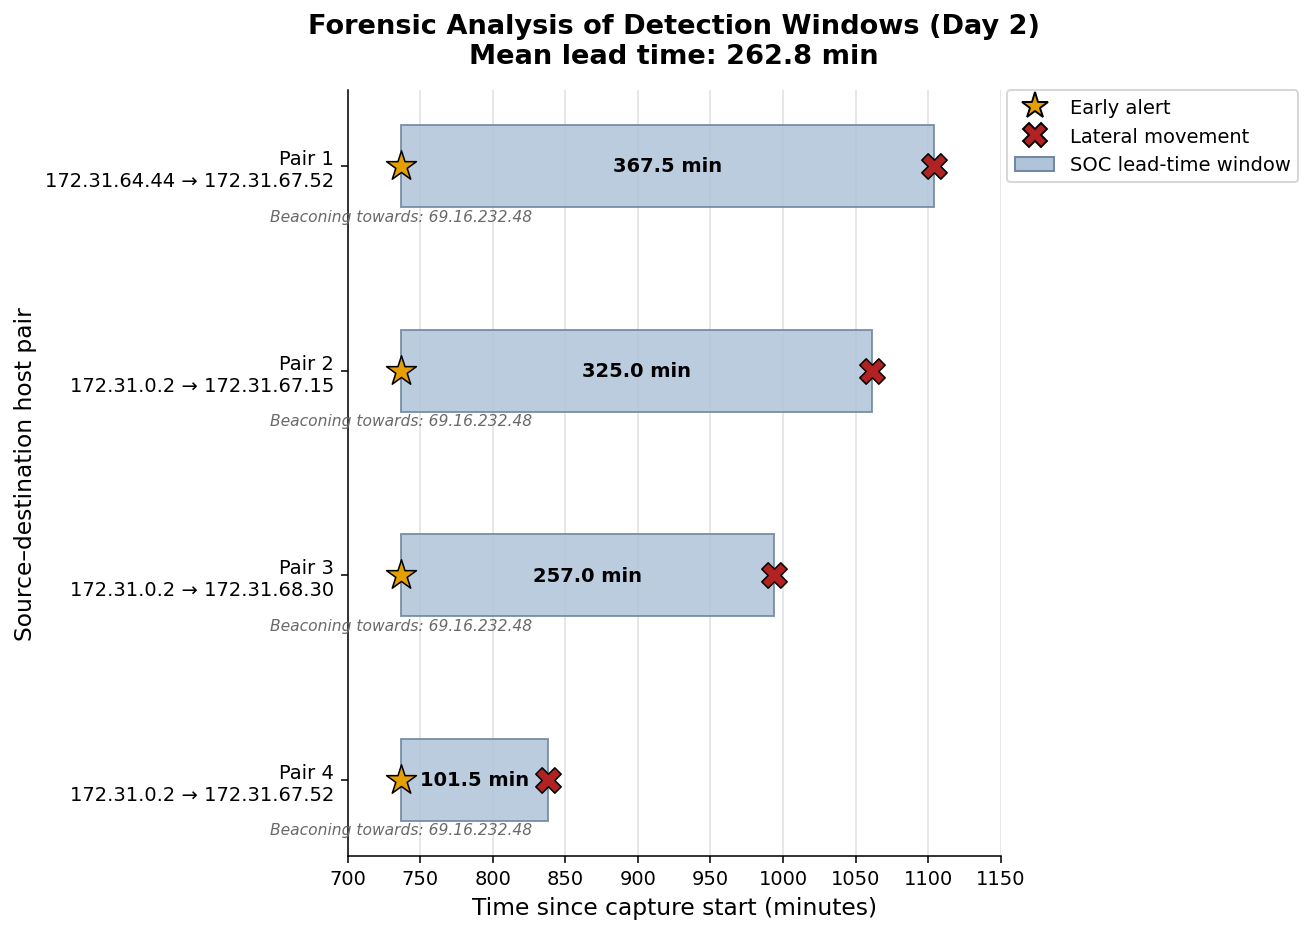

In [39]:
# =========================================================
# 1. DATA PREP
# =========================================================
df_plot = df_lm_pairs.copy()

# Choose the sorting criterion
# Option A: sort by lateral movement time (largest on top)
df_plot = df_plot.sort_values(by='Lateral_Movement_Min', ascending=False).reset_index(drop=True)

# If we want Pair 1 at the bottom, keep y positions normal and invert the y-axis later.
# Labels in English
y_labels = [
    f"Pair {i+1}\n{row['LM_Source']} → {row['LM_Dest']}"
    for i, row in df_plot.iterrows()
]

avg_lead_time = df_plot['Lead_Time_Min'].mean()

# =========================================================
# 2. FIGURE STYLE
# =========================================================
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans"
})

fig, ax = plt.subplots(figsize=(11.5, 6.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Softer, paper-friendly colors
bar_color = "#AFC4DA"        # muted blue
bar_edge = "#6E86A0"
alert_color = "#E69F00"      # colorblind-friendly orange
lm_color = "#B22222"         # dark red

y_positions = np.arange(len(df_plot))
bar_height = 0.40

# =========================================================
# 3. PLOT ELEMENTS
# =========================================================
# Lead-time window
bars = ax.barh(
    y_positions,
    df_plot["Lead_Time_Min"],
    left=df_plot["First_Alert_Min"],
    height=bar_height,
    color=bar_color,
    edgecolor=bar_edge,
    linewidth=1.0,
    alpha=0.85,
    zorder=2
)

# Early alert marker
ax.scatter(
    df_plot["First_Alert_Min"],
    y_positions,
    color=alert_color,
    edgecolor="black",
    linewidth=0.8,
    marker="*",
    s=260,
    zorder=4
)

# Lateral movement marker
ax.scatter(
    df_plot["Lateral_Movement_Min"],
    y_positions,
    color=lm_color,
    edgecolor="black",
    linewidth=0.8,
    marker="X",
    s=170,
    zorder=4
)

# =========================================================
# 4. ANNOTATIONS
# =========================================================
for i, row in df_plot.iterrows():
    start = row["First_Alert_Min"]
    end = row["Lateral_Movement_Min"]
    lead = row["Lead_Time_Min"]
    center = start + lead / 2

    detalle = row["Forensic_Detail"]

    # Lead time text inside the bar
    ax.text(
        center, y_positions[i],
        f"{lead:.1f} min",
        ha="center", va="center",
        fontsize=10, fontweight="bold", color="black",
        zorder=5
    )

    # Milestone labels slightly above markers
    # ax.annotate(
    #     "Early alert",
    #     xy=(start, y_positions[i]),
    #     xytext=(0, 16),
    #     textcoords="offset points",
    #     ha="center", va="bottom",
    #     fontsize=9, color=alert_color, fontweight="bold"
    # )

    ax.annotate(
        detalle,
        xy=(start, y_positions[i]),
        xytext=(0, -22),
        textcoords="offset points",
        ha="center", va="top",
        fontsize=8, color="dimgray", style="italic",
        zorder=6
    )

    # ax.annotate(
    #     "Lateral movement",
    #     xy=(end, y_positions[i]),
    #     xytext=(0, 16),
    #     textcoords="offset points",
    #     ha="center", va="bottom",
    #     fontsize=9, color=lm_color, fontweight="bold"
    # )




# =========================================================
# 5. AXES, TICKS, GRID
# =========================================================
ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels)

ax.set_xlim(700, 1150)
ax.set_xlabel("Time since capture start (minutes)")
ax.set_ylabel("Source–destination host pair")

ax.set_title(
    f"Forensic Analysis of Detection Windows (Day 2)\n"
    f"Mean lead time: {avg_lead_time:.1f} min",
    pad=14,
    fontweight="bold"
)

# If we want Pair 1 at the bottom:
ax.invert_yaxis()

# Tick formatting: t = ...
#ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"t={int(x)}"))

# Subtle grid for paper
ax.grid(axis="x", color="#D9D9D9", linewidth=0.8, alpha=0.8)
ax.grid(axis="y", visible=False)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =========================================================
# 6. LEGEND OUTSIDE THE PLOT
# =========================================================
legend_handles = [
    Line2D([0], [0], marker="*", color="w",
           markerfacecolor=alert_color, markeredgecolor="black",
           markersize=14, label="Early alert"),
    Line2D([0], [0], marker="X", color="w",
           markerfacecolor=lm_color, markeredgecolor="black",
           markersize=12, label="Lateral movement"),
    Patch(facecolor=bar_color, edgecolor=bar_edge,
          label="SOC lead-time window")
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=True,
    borderaxespad=0.0
)

# Leave space on the right for the legend
plt.tight_layout(rect=[0, 0, 0.83, 1])

# Best format for paper
# plt.savefig("forensic_detection_windows_day1.pdf", bbox_inches="tight")
# plt.savefig("forensic_detection_windows_day1.png", bbox_inches="tight", dpi=300)

plt.show()